<a href="https://colab.research.google.com/github/MELCHIOR123-bot/Computer_Vision/blob/main/2_Layer_Deep_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3

CLASS_NAMES = ["daisy", "dandelion","roses","sunflowers","tulips"]

In [ ]:
def read_and_decode(filename, resize_dims):
  # Read the raw file
  img_bytes = tf.io.read_file(filename)
  # Decode image data
  img = tf.image.decode_jpeg(img_bytes, channels=IMG_CHANNELS)
  # Convert pixel values to floats in [0,1]
  img = tf.image.convert_image_dtype(img, tf.float32)
  # Resize the image to match desired dimesions
  img = tf.image.resize(img, resize_dims)
  return img

In [ ]:
def parse_csvline(csv_line):
  # record defaults specify teh data types for each column
  record_default = ["",""]
  filename, label_string = tf.io.decode_csv(csv_line, record_default)
  # Load image
  img = read_and_decode(filename,[IMG_HEIGHT, IMG_WIDTH])
  # Convert label string to integer based on the class_names index
  label = tf.argmax(tf.math.equal(CLASS_NAMES, label_string))
  return img, label

In [ ]:
train_dataset = (
    tf.data.TextLineDataset("gs://cloud-ml-data/img/flower_photos/train_set.csv")
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)
eval_dataset = (
    tf.data.TextLineDataset("gs://cloud-ml-data/img/flower_photos/eval_set.csv")
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
for image_batch, label_batch in train_dataset.take(2):
  print("Image batch shape:", image_batch.shape)
  print("Label batch shape:", label_batch.shape)
  print("Label:",label_batch.numpy())

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Label: [0 1 1 1 0 2 1 0 4 3 0 3 1 4 4 1]
Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Label: [0 3 2 1 0 4 2 0 2 2 1 3 3 2 1 0]


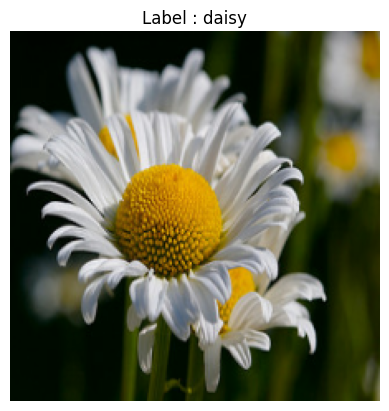

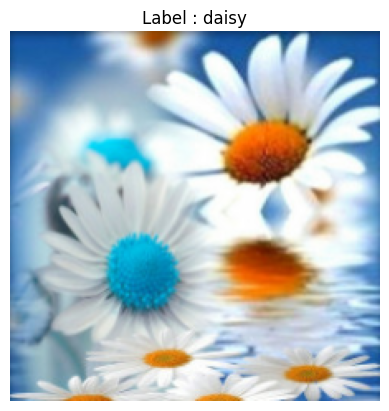

In [ ]:
import matplotlib.pyplot as plt
for image_batch, label_batch in train_dataset.take(2):
  # Take the first image from the batch
  first_image = image_batch[0]
  first_label = label_batch[0]

  # convert tensor to numpy array
  plt.imshow(first_image.numpy())
  plt.title(f"Label : {CLASS_NAMES[first_label]}")
  plt.axis("off")
  plt.show()

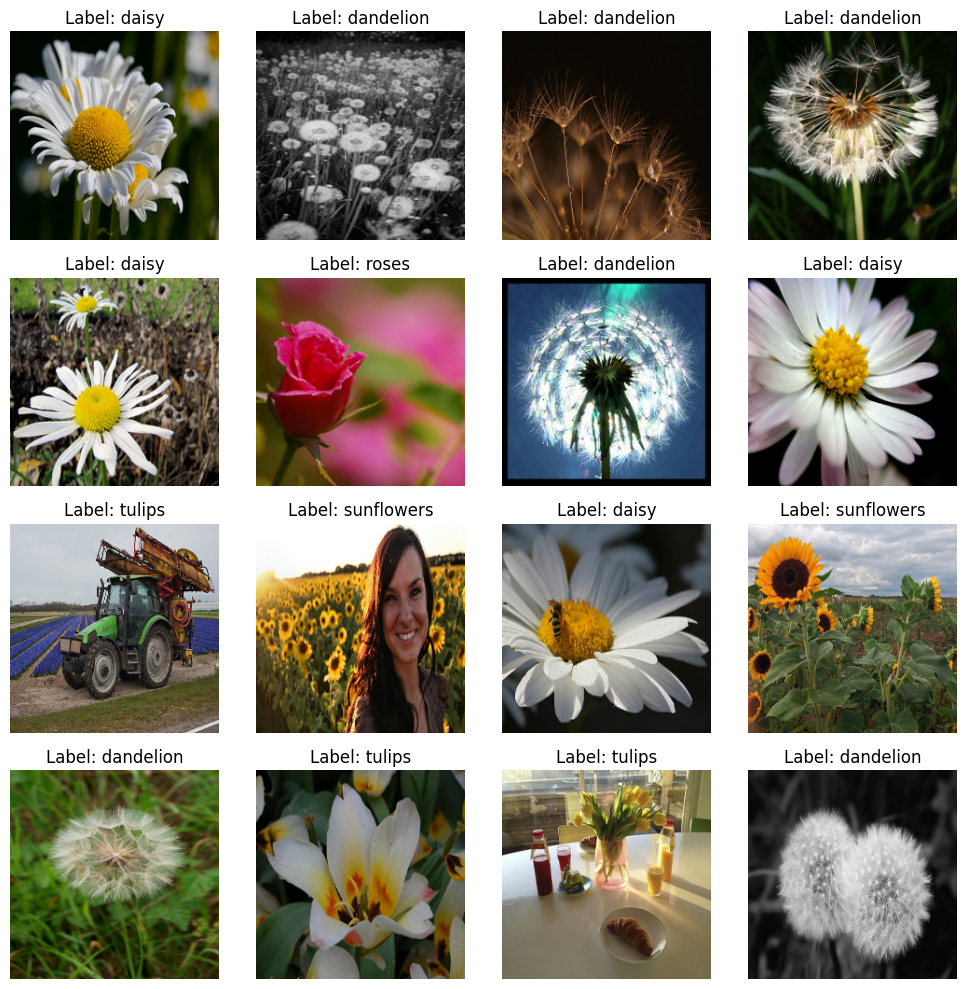

In [ ]:
# Take one batch from the dataset
for image_batch, label_batch in train_dataset.take(1):
  fig, axes = plt.subplots(4,4, figsize=(10,10))
  for i in range(16):
    ax = axes[i //4, i%4] # Determine grid position
    ax.imshow(image_batch[i].numpy()) # Convert tensor to numpy array
    ax.set_title(f"Label: {CLASS_NAMES[label_batch[i]]}")
    ax.axis("off") # Hide axes

  plt.tight_layout()
  plt.show()

In [ ]:
from tensorflow import keras
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(len(CLASS_NAMES),activation="softmax")
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [ ]:
EPOCHS = 10
history = model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=EPOCHS
)

Epoch 1/10
    207/Unknown 446s 2s/step - accuracy: 0.2298 - loss: 1704.7952

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


207/207 ━━━━━━━━━━━━━━━━━━━━ 494s 2s/step - accuracy: 0.2298 - loss: 1698.6149 - val_accuracy: 0.2351 - val_loss: 1.6076
Epoch 2/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 527s 3s/step - accuracy: 0.2367 - loss: 1.6101 - val_accuracy: 0.2351 - val_loss: 1.6080
Epoch 3/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 437s 2s/step - accuracy: 0.2372 - loss: 1.6112 - val_accuracy: 0.2351 - val_loss: 1.6082
Epoch 4/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 444s 2s/step - accuracy: 0.2383 - loss: 1.6117 - val_accuracy: 0.2351 - val_loss: 1.6083
Epoch 5/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 490s 2s/step - accuracy: 0.2390 - loss: 1.6120 - val_accuracy: 0.2351 - val_loss: 1.6083
Epoch 6/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 429s 2s/step - accuracy: 0.2366 - loss: 1.6122 - val_accuracy: 0.2351 - val_loss: 1.6084
Epoch 7/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 413s 2s/step - accuracy: 0.2372 - loss: 1.6123 - val_accuracy: 0.2351 - val_loss: 1.6084
Epoch 8/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 421s 2s/step - accuracy: 0.2359 - loss: 1.6124 - val_accuracy: 0.

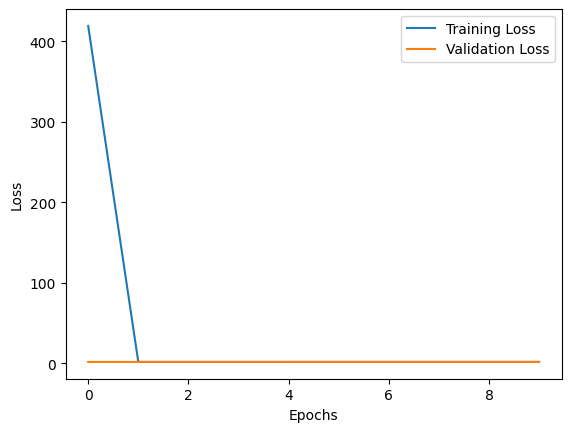

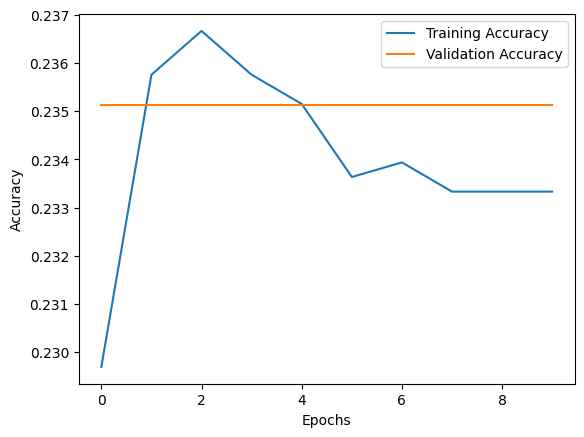

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


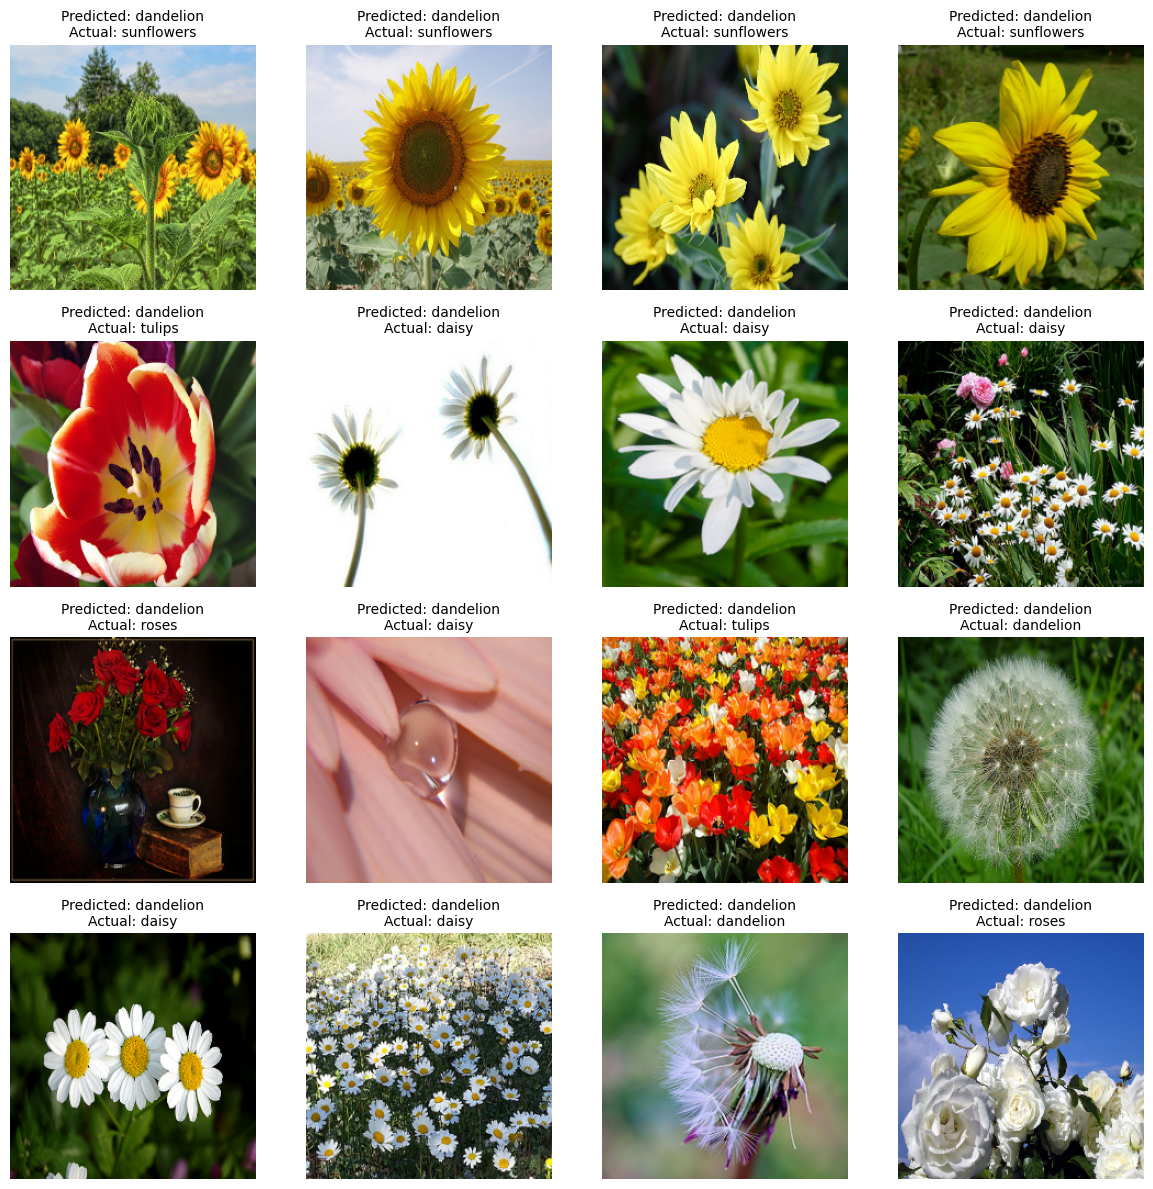

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


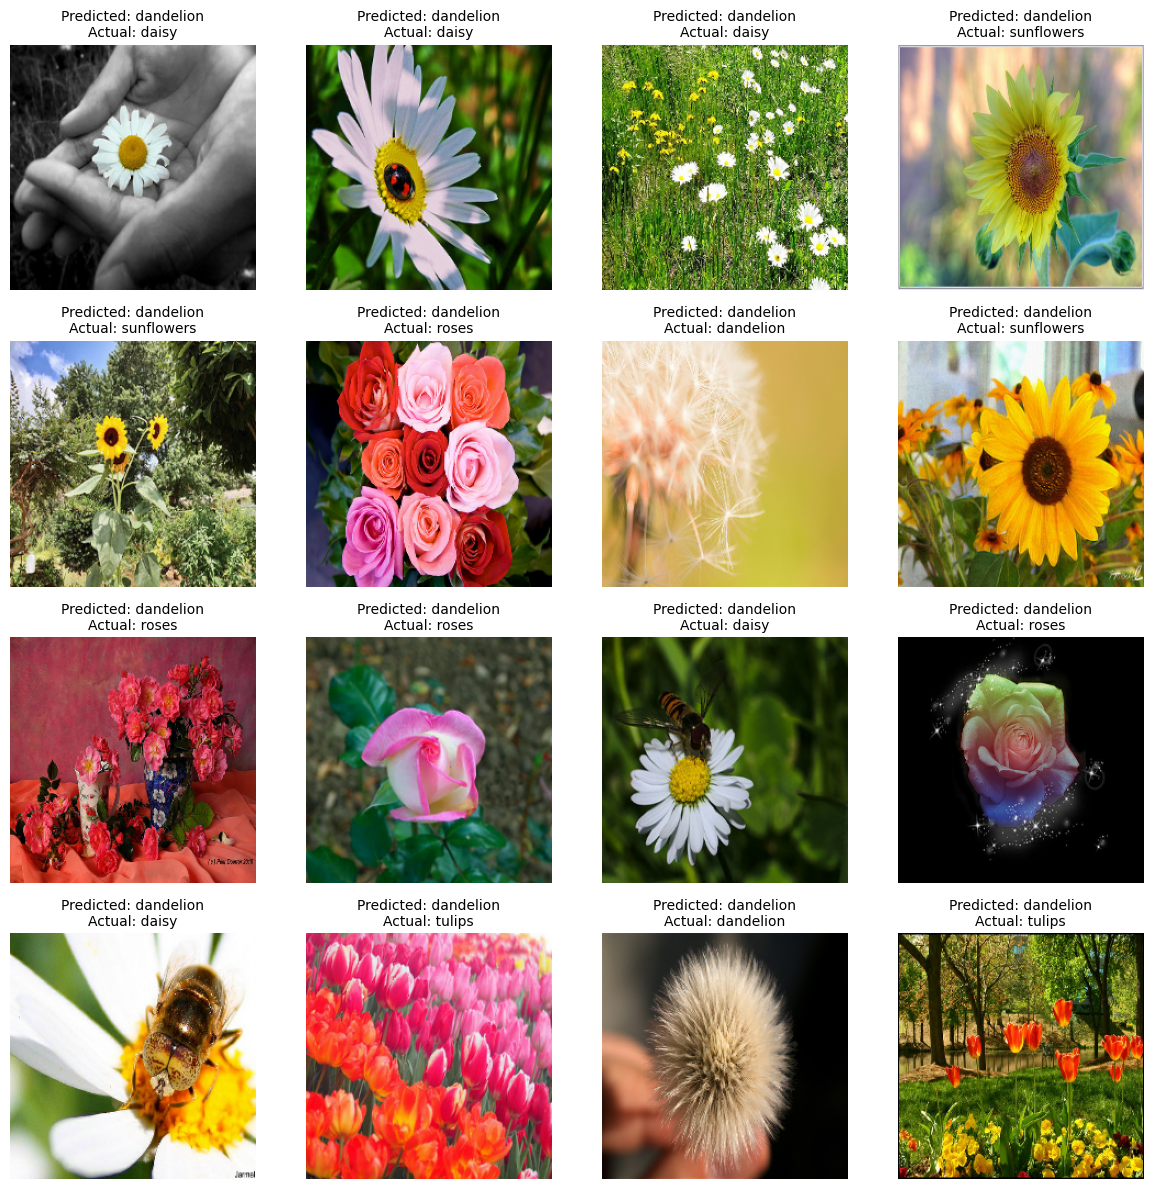

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
# Take exactly one batch from evaluation dataset
for images, labels in eval_dataset.take(2):
  # Get model predictions for this batch
  batch_predictions = model.predict(images)
  predicted_indices = np.argmax(batch_predictions, axis=1)
  # Number of images in this batch
  num_images = images.shape[0]
  #configure how mny images to display per row
  num_cols = 4
  num_rows = math.ceil(num_images/num_cols)
  # create a figure with  as suitable size
  plt.figure(figsize=(12, 3*num_rows))
  for i in range(num_images):
      plt.subplot(num_rows, num_cols, i+1)
      #Display the image
      plt.imshow(images[i].numpy())
      plt.axis('off')

      #Get predicted and actual class names
      pred_class = CLASS_NAMES[predicted_indices[i]]
      actual_class = CLASS_NAMES[labels[i].numpy()]

      # show both predicted and actual labels as title
      plt.title(f"Predicted: {pred_class}\nActual: {actual_class}",fontsize=10)
  # Adjust spacing to avoid overlapping titles,etc.
  plt.tight_layout()
  plt.show()